In [21]:
import matplotlib.pyplot as plt
import random
import time

In [19]:
def compare_sorts_plot():
    def insertion_sort(arr):
        arr = arr.copy()
        for i in range(1, len(arr)):
            key = arr[i]
            j = i - 1
            while j >= 0 and arr[j] > key:
                arr[j + 1] = arr[j]
                j -= 1
            arr[j + 1] = key
        return arr

    def merge_sort(arr):
        if len(arr) <= 1:
            return arr.copy()
        
        mid = len(arr) // 2
        left = merge_sort(arr[:mid])
        right = merge_sort(arr[mid:])
        
        result = []
        i = j = 0
        while i < len(left) and j < len(right):
            if left[i] <= right[j]:
                result.append(left[i])
                i += 1
            else:
                result.append(right[j])
                j += 1
        
        result.extend(left[i:])
        result.extend(right[j:])
        return result
    
    def benchmark_sorting():
        sizes = list(range(5, 201, 5))
        insertion_times = []
        merge_times = []
        
        for size in sizes:
            # Create random array
            arr = [random.randint(1, 1000) for _ in range(size)]
            
            # Time insertion sort
            start = time.perf_counter()
            for _ in range(100):  # Multiple runs for better timing
                insertion_sort(arr)
            insertion_time = time.perf_counter() - start
            insertion_times.append(insertion_time)
            
            # Time merge sort
            start = time.perf_counter()
            for _ in range(100):
                merge_sort(arr)
            merge_time = time.perf_counter() - start
            merge_times.append(merge_time)
        
        return sizes, insertion_times, merge_times
    
    # Run benchmark
    print("Benchmarking sorting algorithms...")
    sizes, insertion_times, merge_times = benchmark_sorting()
    
    # Create plot
    plt.figure(figsize=(6, 6))
    plt.plot(sizes, insertion_times, 'o-', label='Insertion Sort O(n²)', 
             color='#e74c3c', linewidth=2, markersize=4)
    plt.plot(sizes, merge_times, 's-', label='Merge Sort O(n log n)', 
             color='#3498db', linewidth=2, markersize=4)
    
    # Find crossover point
    crossover = None
    for i in range(len(insertion_times)):
        if merge_times[i] < insertion_times[i]:
            crossover = sizes[i]
            break
    
    if crossover:
        plt.axvline(x=crossover, color='red', linestyle='--', alpha=0.7)
        plt.text(crossover + 10, max(insertion_times) * 0.8, 
                 f'Crossover ~{crossover}', rotation=90, color='red')
    
    plt.xlabel('Array Size')
    plt.ylabel('Time (seconds)')
    plt.title('Sorting Algorithms: When Does Asymptotic Complexity Matter?')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nResults:")
    print(f"Merge sort becomes faster than insertion sort around size: {crossover}")
    print(f"For small arrays (< {crossover}), insertion sort wins despite being O(n²)!")
    print(f"This shows that constant factors can dominate for practical problem sizes.")

# 3.2.A Complexity Analysis

### Big-$\small\mathcal{O}$.

We now formalize discussions about running time analysis. So far, we have been measuring the running time in seconds. However, this may not be the best idea for measuring performance as it depends on the processing power and local environment of the machine it is being run on. Ideally, we would like to measure performance in a way that is invariant of the local machine we are using and in a way that allows us to naturally make comparisons between different algorithms.

The main idea behind big-$\mathcal{O}$ notation is that rather than directly asking how fast the algorithm runs in seconds, we are interested instead in how the performance scales with the size of the input. This is the fundamental characteristic that we are interested in any way and as we will see, also allows us to ignore irrelevant implementation details. Furthermore, 

### Emperical Verification.

### Caveat emptor: Hidden Constants.

As much as the theorists may like asymptotic analysis and big-$\mathcal{O}$, there are certain practical limitations that one should be aware of. One of the biggest benefits of such notation is that it suppresses constant additive and multiplicative factors. That is $c_1 \cdot f(n) + c_2 \in \mathcal{O}(f)$. However, while asymptotically constant factors aren't that important, in the regime of problem sizes that we may practically care about, such constant factors may be very important. Consider the following example:

In [16]:
def f(x):
    for _ in range(1_000_000):
        1 + 1

The program runs for exactly $1000000$ iterations, which is a constant with respect to our input $x$. Thus, under our notation, this qualifies as a $\mathcal{O}(1)$ algorithm. Admittedly, this is a ludicrous and artificial example. For a more realistic example that we will be discussing more in the following weeks, consider the comparison between two sorting algorithms below.

Benchmarking sorting algorithms...


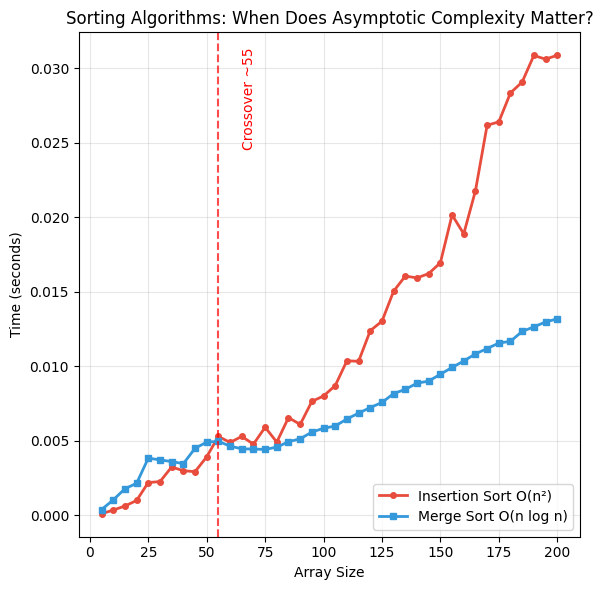


Results:
Merge sort becomes faster than insertion sort around size: 55
For small arrays (< 55), insertion sort wins despite being O(n²)!
This shows that constant factors can dominate for practical problem sizes.


In [20]:
compare_sorts_plot()

There are many, more involved examples that illustrate this problem better. Theorists are often motivated to design asymptotically polynomial time algorithms due to complexity implications. However, not all such algorithms prove to be practically useful. These are colorfully known as [galactic algorithms](https://en.wikipedia.org/wiki/Galactic_algorithm).

## Exercises